# Results

In [1]:
import pandas as pd
from src.helpers.metrics import  build_metrics_table

from experiment_config import DATA_NAME,N_REP,PRED_DIR,ESTIMATION_DIR

DATA_NAME 

'DS05'

## Load Predictions

In [2]:
df_preds = pd.read_csv(PRED_DIR /f"rul_test_rep{N_REP}.csv")

## Compute mean prediction

In [3]:
df_preds = df_preds.groupby(["unit", "time"], as_index=False).mean()

## Full-life Predictions

In [4]:
metrics_full = build_metrics_table(df_preds)
metrics_full = metrics_full.drop(columns=["unit"]).mean()
metrics_full.name = "full life"

## Benchmark Predictions (RUL<65)

In [5]:
df_benchmark = df_preds[df_preds["true_rul"] <= 65]
metrics_rul65 = build_metrics_table(df_benchmark)
metrics_rul65 = metrics_rul65.drop(columns=["unit"]).mean()
metrics_rul65.name = "RUL <= 65"

## Degradation Predictions

In [6]:
hi_df = pd.read_csv(ESTIMATION_DIR/'data_test.csv')
test_units = hi_df['unit'].astype(int).unique().tolist()
onsets = {unit: hi_df[(hi_df['unit']==unit) & (hi_df['hs']==0)]['cycle'].values[0] for unit in test_units}
df_degpreds = df_preds[
    df_preds["time"] > df_preds["unit"].map(onsets)
]

In [7]:
metrics_deg = build_metrics_table(df_degpreds)
metrics_deg = metrics_deg.drop(columns=["unit"]).mean()
metrics_deg.name = "degradation"

## Combine

In [8]:
results_table = pd.concat(
    [metrics_full, metrics_rul65, metrics_deg],
    axis=1
)

results_table.index.name = DATA_NAME

results_table

,full life,RUL <= 65,degradation
DS05,,,
RMSE,8.120079,6.442034,4.370916
Score,71.405129,38.987265,20.992216
PICP,0.948816,0.935606,0.914299
PINAW,0.492673,0.512198,0.500147


## Save

In [9]:
results_table.to_csv(PRED_DIR / f"mea{N_REP}_results.csv")

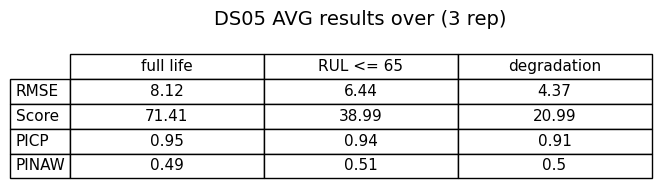

In [10]:
import matplotlib.pyplot as plt

# Round for presentation
table_df = results_table.round(2)

fig, ax = plt.subplots(figsize=(7, 2))
ax.axis('off')

table = ax.table(
    cellText=table_df.values,
    rowLabels=table_df.index,
    colLabels=table_df.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 1.8)

plt.title(f"{DATA_NAME} AVG results over ({N_REP} rep)", fontsize=14, pad=20)
plt.tight_layout()

plt.savefig(PRED_DIR / f"mean{N_REP}_results.png", dpi=400)
plt.show()
plt.close()

| DS01	 | full      | RUL65     | deg       |
|--------|-----------|-----------|-----------|
| RMSE   | 5.068149  | 4.803219  | 4.711211  |
| Score  | 52.206928 | 37.873358 | 28.425670 |
| PICP   | 0.953896  | 0.943182  | 0.920168  |
| PINAW  | 0.312042  | 0.338091  | 0.337272  |

| DS01  | full      | RUL65     | deg       |
|-------|-----------|-----------|-----------|
| RMSE  | 5.911671  | 5.489353  | 4.825945  |
| Score | 54.152342 | 37.978099 | 25.271517 |
| PICP  | 1.000000  | 1.000000  | 1.000000  |
| PINAW | 0.451564  | 0.453165  | 0.460341  |

| DS03	 | full      | RUL65     | deg       |
|--------|-----------|-----------|-----------|
| RMSE   | 7.654103  | 7.383116  | 4.767812  |
| Score  | 71.544372 | 57.373969 | 22.033015 |
| PICP   | 0.926416  | 0.909519  | 0.913396  |
| PINAW  | 0.394850  | 0.398448  | 0.403939  |

| DS05   | full      | RUL65     | deg       |
|--------|-----------|-----------|-----------|
| RMSE   | 6.065781  | 5.153894  | 3.125471  |
| Score  | 45.452652 | 28.057284 | 13.593670 |
| PICP   | 0.988020  | 0.984848  | 0.980692  |
| PINAW  | 0.397921  | 0.422600  | 0.448572  |

| DS06   | full      | RUL65     | deg	     |
|--------|-----------|-----------|-----------|
| RMSE   | 6.697169  | 5.585590  | 4.804076  |
| Score  | 71.535756 | 39.490416 | 27.586838 |
| PICP   | 0.877232  | 0.920455  | 0.940313  |
| PINAW  | 0.324644  | 0.374098  | 0.430793  |